# 2. Histogram Processing


## 2.1. Introduction


A histogram of a digital image with intensity levels in the range $[0, L−1]$ is a discrete function that counts how many pixels in the image have each possible intensity value. It gives a global statistical summary of the brightness distribution meaning you can immediately see whether an image is dark (histogram shifted left), bright (shifted right), low-contrast (narrow peak), or high-contrast (spread wide).

For an 8-bit grayscale image, $L = 256$, so the histogram has $256$ bins, one for each intensity level $r_k = 0, 1, 2, ... 255$.

The unnormalized (raw count) histogram is defined as:

$$
h(r_k) = n_k
$$

Where, <br>
$\qquad r_k =$ Intensity level $k$ $(k = 0, 1, 2, ..., L−1)$ <br>
$\qquad n_k =$ Number of pixels with intensity $r_k$ <br>
$\qquad L =$ Total number of intensity levels ($256$ for 8-bit) <br>

The normalized histogram (probability estimate) is:

$$
p(r_k) = \frac{n_k}{MN}
$$

Where, <br>
$\qquad M =$ Number of rows (image height in pixels) <br>
$\qquad N =$ Number of columns (image width in pixels) <br>
$\qquad MN =$ Total number of pixels in the image <br>

and: $\sum{p(r_k)} = 1$ for $k = 0$ to $L−1$


**Program to implement histogram of an image**


In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
img = cv2.imread("images/img-2.png", 0)

if img is None:
    print("Image not found!")
    exit()

In [7]:
M, N = img.shape

# calcHist(images, channels, mask, histSize, ranges)
h = cv2.calcHist([img], [0], None, [256], [0, 256])
h = h.flatten()

p = h / (M * N)

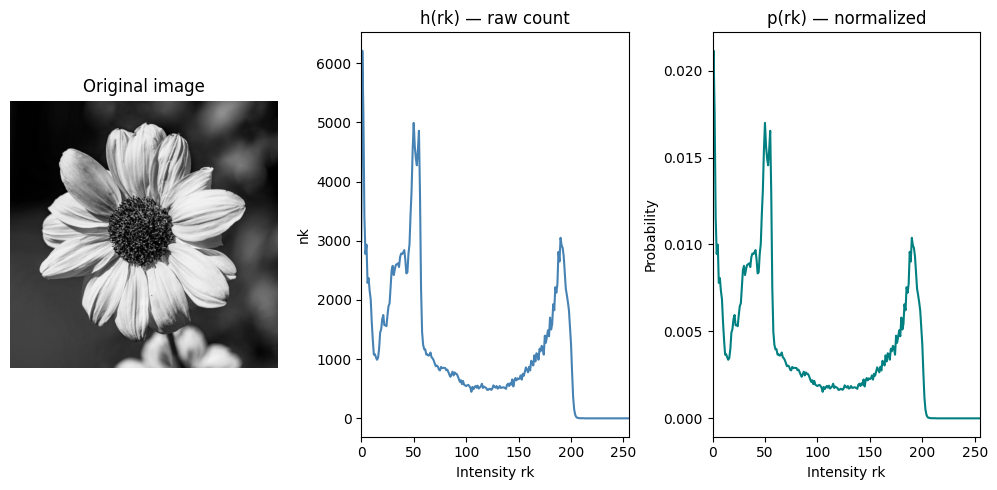

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.plot(h, color="steelblue")
plt.title("h(rk) — raw count")
plt.xlim([0, 255])
plt.xlabel("Intensity rk")
plt.ylabel("nk")

plt.subplot(1, 3, 3)
plt.plot(p, color="teal")
plt.title("p(rk) — normalized")
plt.xlim([0, 255])
plt.xlabel("Intensity rk")
plt.ylabel("Probability")

plt.tight_layout()
plt.show()